# Practice 04 — Unsupervised Learning

Given `X` alone, find structure in it.

| Family | Question | Methods |
|:---|:---|:---|
| Clustering | which samples belong together? | Hierarchical, K-means, DBSCAN |
| Dimensionality reduction | can the features be compressed? | PCA, t-SNE |

Iris does have labels.
**They are set aside and never used for fitting**, and come back only at the end to ask how close the
discovered structure is to the known one — a check real unlabelled data does not offer.

With no target there is no accuracy, and *"the algorithm found three groups"* is not the same statement as
*"it found the right three groups"*.

---
## Step 0. Imports

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'   # must be set before sklearn is imported

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.datasets import load_iris, make_moons
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score

np.random.seed(42)
plt.rcParams['axes.unicode_minus'] = False

---
## Step 1. Data — Features Only

**No train/test split.** A split estimates behaviour on unseen data; clustering makes no prediction about
future samples, it describes the set it was given.

**Standardization is not optional.** Every method here measures distances, and petal length spans about 6 cm
against petal width's 2.4 cm — unscaled, petal length would count nearly three times as much for no reason
but its unit.

X: (150, 4)
raw    - mean [5.843 3.057 3.758 1.199], std [0.825 0.434 1.759 0.76 ]
scaled - mean [-0. -0. -0. -0.], std [1. 1. 1. 1.]


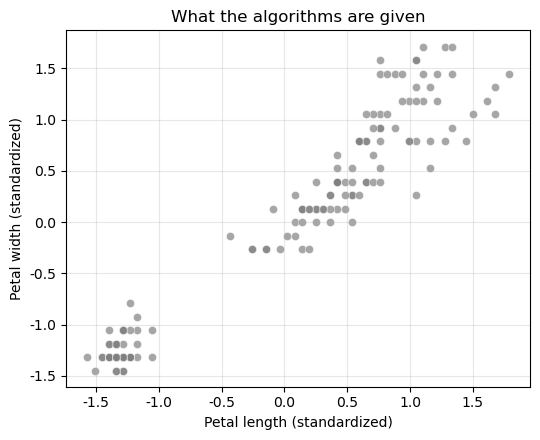

In [2]:
iris = load_iris()

X_raw  = iris.data          # the features the algorithms will see
y_true = iris.target        # set aside - used only for the final check

feature_mean = X_raw.mean(axis=0)
feature_std  = X_raw.std(axis=0)
feature_std[feature_std == 0] = 1.0

X = (X_raw - feature_mean) / feature_std

print(f'X: {X.shape}')
print(f'raw    - mean {X_raw.mean(axis=0).round(3)}, std {X_raw.std(axis=0).round(3)}')
print(f'scaled - mean {X.mean(axis=0).round(3)}, std {X.std(axis=0).round(3)}')

plt.figure(figsize=(5.5, 4.5))
plt.scatter(X[:, 2], X[:, 3], c='gray', s=35, alpha=0.7, edgecolors='white', linewidths=0.5)
plt.xlabel('Petal length (standardized)')
plt.ylabel('Petal width (standardized)')
plt.title('What the algorithms are given')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Two groups are obvious; whether the right-hand blob is one group or two is the question every method below
answers mechanically, in four dimensions rather than two.

All cluster plots use these same two features so they can be compared.

---
## Step 2. Hierarchical Clustering

Start with every sample as its own cluster, repeatedly merge the two closest, and record the merges as a
tree — the **dendrogram**.
A clustering is a cut through it at a chosen height, so $k$ is not needed in advance.

"Closest" is what the `method` argument defines:

| `method` | Distance between two clusters |
|:---|:---|
| `single` | closest pair of points |
| `complete` | farthest pair |
| `average` | average over all pairs |
| `centroid` | between the two centroids |
| `ward` | increase in within-cluster sum of squares |

`ward` is the default: it merges whichever pair adds the least spread, so clusters come out compact.

heights of the last 8 merges: [ 3.95  4.06  4.23  4.24  6.61  8.   12.64 27.25]


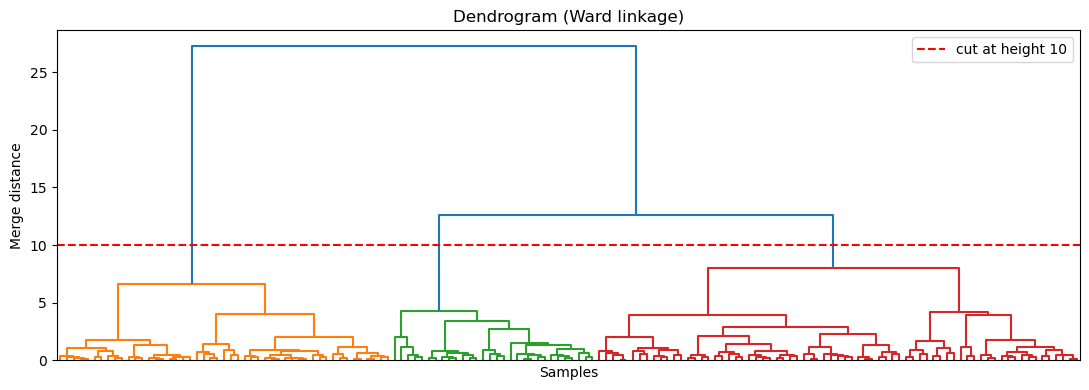

In [3]:
linkage_matrix = linkage(X, method='ward')

# column 2 of the linkage matrix holds the merge heights
print('heights of the last 8 merges:', np.round(linkage_matrix[-8:, 2], 2))

plt.figure(figsize=(11, 4))
dendrogram(linkage_matrix, no_labels=True, color_threshold=10)
plt.axhline(10, color='red', linestyle='--', linewidth=1.5, label='cut at height 10')
plt.xlabel('Samples')
plt.ylabel('Merge distance')
plt.title('Dendrogram (Ward linkage)')
plt.legend()
plt.tight_layout()
plt.show()

The two long vertical lines near the top are expensive merges — joining those groups added far more spread
than anything earlier.
That gap is the argument for cutting below them.

`fcluster` cuts by distance; `AgglomerativeClustering` takes the number of clusters directly.

In [4]:
for height in [4, 6, 8, 10, 14]:
    labels_at_height = fcluster(linkage_matrix, height, criterion='distance')
    print(f'cut at {height:2d} -> {len(np.unique(labels_at_height)):2d} clusters, sizes {np.bincount(labels_at_height)[1:]}')

hierarchical = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X)
print()
print(f'AgglomerativeClustering(n_clusters=3) -> sizes {np.bincount(hierarchical_labels)}')

cut at  4 ->  8 clusters, sizes [20  7 22  5 25 45  8 18]
cut at  6 ->  5 clusters, sizes [20 29 30 45 26]
cut at  8 ->  4 clusters, sizes [49 30 45 26]
cut at 10 ->  3 clusters, sizes [49 30 71]
cut at 14 ->  2 clusters, sizes [ 49 101]

AgglomerativeClustering(n_clusters=3) -> sizes [71 49 30]


---
## Step 3. K-means, and Choosing $k$

Place $k$ centres, assign each point to the nearest, move each centre to the mean of its points, repeat.
It minimises the within-cluster sum of squares, reported as `inertia_`:

$$\text{inertia} = \sum_{k}\sum_{\mathbf{x} \in C_k} \lVert \mathbf{x} - \boldsymbol{\mu}_k \rVert^2$$

`n_init=10` restarts from ten random initialisations and keeps the best.

### Choosing $k$

Inertia falls to zero when every point is its own cluster, so it cannot choose $k$ — what is read is the
**elbow**.
The **silhouette score** compares each sample's mean distance to its own cluster ($a$) with the distance
to the nearest other cluster ($b$):

$$s = \frac{b - a}{\max(a, b)} \in [-1, 1]$$

Higher means tighter and better separated, and unlike inertia it can be maximised.

k = 1   inertia =  600.0   silhouette = -
k = 2   inertia =  222.4   silhouette = 0.5818
k = 3   inertia =  139.8   silhouette = 0.4599
k = 4   inertia =  114.1   silhouette = 0.3869
k = 5   inertia =   90.9   silhouette = 0.3459
k = 6   inertia =   81.5   silhouette = 0.3171
k = 7   inertia =   72.6   silhouette = 0.3202
k = 8   inertia =   62.5   silhouette = 0.3387
k = 9   inertia =   55.1   silhouette = 0.3424


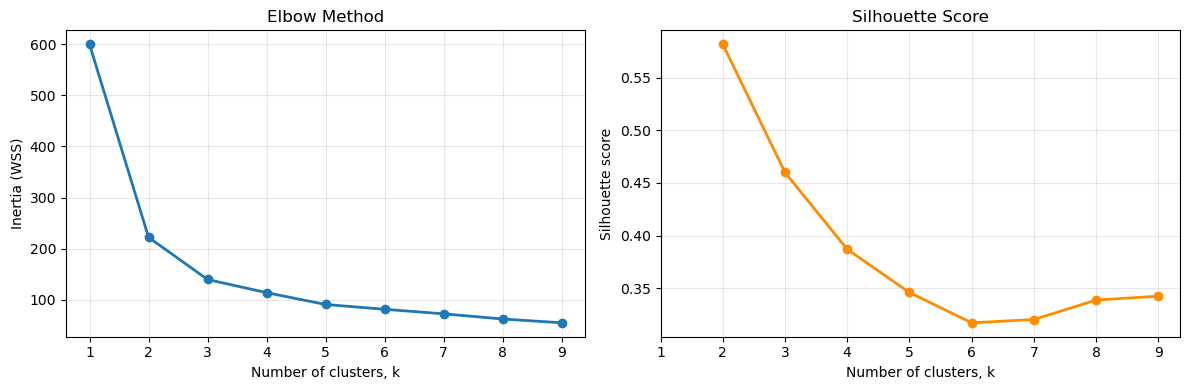

In [5]:
k_values = range(1, 10)
inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)
    # the silhouette needs at least two clusters
    silhouette_values.append(silhouette_score(X, kmeans.labels_) if k > 1 else np.nan)
    print(f'k = {k}   inertia = {kmeans.inertia_:6.1f}   silhouette = '
          f'{silhouette_values[-1]:.4f}' if k > 1 else f'k = {k}   inertia = {kmeans.inertia_:6.1f}   silhouette = -')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_values), inertia_values, 'o-', linewidth=2)
axes[0].set_xlabel('Number of clusters, k'); axes[0].set_ylabel('Inertia (WSS)')
axes[0].set_title('Elbow Method'); axes[0].set_xticks(list(k_values)); axes[0].grid(alpha=0.3)

axes[1].plot(list(k_values), silhouette_values, 'o-', linewidth=2, color='darkorange')
axes[1].set_xlabel('Number of clusters, k'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Score'); axes[1].set_xticks(list(k_values)); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The two guides disagree: the elbow is arguably at $k = 3$, where the steep fall ends, while the silhouette
is highest at $k = 2$.
Iris has three species, and Step 6 returns to this — it is not a defect of either index.

Fitting with $k = 3$:

cluster sizes: [53 50 47]
inertia      : 139.82


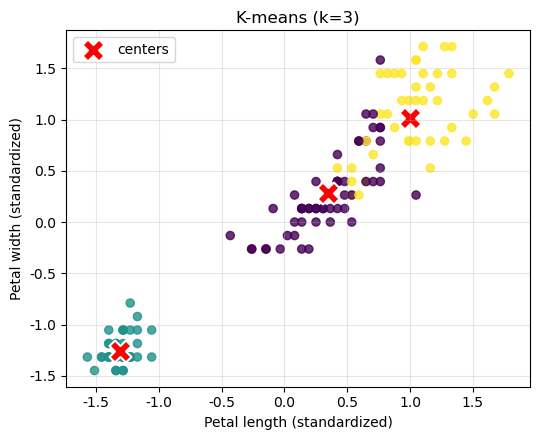

In [6]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

print(f'cluster sizes: {np.bincount(kmeans_labels)}')
print(f'inertia      : {kmeans.inertia_:.2f}')

plt.figure(figsize=(5.5, 4.5))
plt.scatter(X[:, 2], X[:, 3], c=kmeans_labels, cmap='viridis', s=35, alpha=0.8)
plt.scatter(centers[:, 2], centers[:, 3], c='red', marker='X', s=250, edgecolors='white', linewidths=1.5, label='centers')
plt.xlabel('Petal length (standardized)')
plt.ylabel('Petal width (standardized)')
plt.title('K-means (k=3)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 4. DBSCAN

A cluster is a dense region; everything outside every dense region is **noise**.

- `eps` — radius of the neighbourhood around a point
- `min_samples` — points needed inside it to make a *core point*

Core points within `eps` of each other chain into one cluster; the rest are labelled **`-1`**, a label no
other method here produces.
The number of clusters is never specified, but `eps` is, and it depends on the scale of the data.

eps = 0.5 -> 2 clusters, 34 noise points
eps = 0.7 -> 2 clusters,  6 noise points
eps = 0.8 -> 2 clusters,  4 noise points
eps = 1.0 -> 2 clusters,  3 noise points
eps = 1.2 -> 2 clusters,  1 noise points

chosen eps = 0.8
  clusters     : 2   (label -1 is noise, not a cluster)
  cluster sizes: [49 97]
  noise points : 4


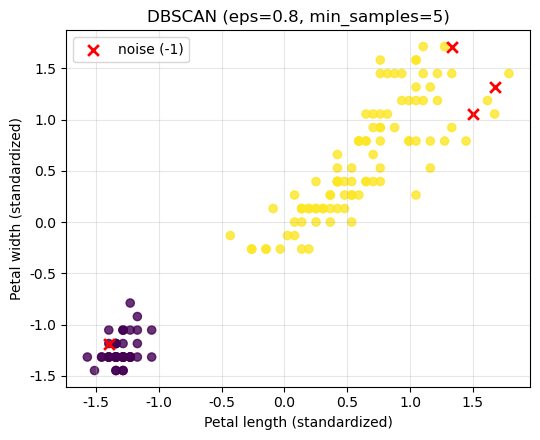

In [7]:
for eps in [0.5, 0.7, 0.8, 1.0, 1.2]:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels_at_eps = dbscan.fit_predict(X)
    cluster_ids = set(labels_at_eps)
    cluster_ids.discard(-1)          # -1 marks noise, not a cluster
    n_noise = int((labels_at_eps == -1).sum())
    print(f'eps = {eps:.1f} -> {len(cluster_ids)} clusters, {n_noise:2d} noise points')

dbscan = DBSCAN(eps=0.8, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

cluster_ids = set(dbscan_labels)
cluster_ids.discard(-1)              # -1 marks noise, not a cluster

print()
print(f'chosen eps = 0.8')
print(f'  clusters     : {len(cluster_ids)}   (label -1 is noise, not a cluster)')
print(f'  cluster sizes: {np.bincount(dbscan_labels[dbscan_labels >= 0])}')
print(f'  noise points : {int((dbscan_labels == -1).sum())}')

plt.figure(figsize=(5.5, 4.5))
is_noise = dbscan_labels == -1
plt.scatter(X[~is_noise, 2], X[~is_noise, 3], c=dbscan_labels[~is_noise], cmap='viridis', s=35, alpha=0.8)
plt.scatter(X[is_noise, 2], X[is_noise, 3], c='red', marker='x', s=60, linewidths=2, label='noise (-1)')
plt.xlabel('Petal length (standardized)')
plt.ylabel('Petal width (standardized)')
plt.title('DBSCAN (eps=0.8, min_samples=5)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

At every `eps` in the sweep DBSCAN finds **two** clusters, not three.
The two right-hand species touch each other in feature space, so to a density-based method they form one
connected region.
Lowering `eps` to force them apart does not split them; it turns their sparse edges into noise instead.

---
## Step 5. Evaluating a Clustering

| Kind | Index | Needs labels | Asks |
|:---|:---|:---|:---|
| Internal | silhouette | no | are the clusters tight and far apart |
| External | Adjusted Rand Index | yes | do clustering and truth agree, pair by pair |

The silhouette works on any dataset, which is the point — real unlabelled data has nothing else.
ARI is corrected so a random assignment scores 0 and an identical one scores 1, and it ignores cluster
names.
It is available here only because Iris happens to come with labels.

In [8]:
# the silhouette treats DBSCAN's noise label as if it were one more cluster,
# so its value for DBSCAN is only indicative
rows = [
    {'labels': 'Hierarchical (k=3)', 'silhouette': silhouette_score(X, hierarchical_labels),
     'ARI vs truth': adjusted_rand_score(y_true, hierarchical_labels)},
    {'labels': 'K-means (k=3)',      'silhouette': silhouette_score(X, kmeans_labels),
     'ARI vs truth': adjusted_rand_score(y_true, kmeans_labels)},
    {'labels': 'DBSCAN (eps=0.8)',   'silhouette': silhouette_score(X, dbscan_labels),
     'ARI vs truth': adjusted_rand_score(y_true, dbscan_labels)},
    {'labels': 'the true species',   'silhouette': silhouette_score(X, y_true),
     'ARI vs truth': adjusted_rand_score(y_true, y_true)},
]
display(pd.DataFrame(rows).round(4))

,labels,silhouette,ARI vs truth
0,Hierarchical (k=3),0.4467,0.6153
1,K-means (k=3),0.4599,0.6201
2,DBSCAN (eps=0.8),0.5217,0.5518
3,the true species,0.3811,1.0000


**The true labelling has the worst silhouette of the four** — 0.381, below K-means at 0.460 and DBSCAN at
0.522.

Not a bug: the silhouette measures compactness against separation, and two of the three species overlap.

- A high silhouette is evidence about shape, not about correctness — the same index peaked at $k = 2$
  earlier.
- Where labels exist, add an external index: ARI puts hierarchical and K-means (0.615, 0.620) above
  DBSCAN (0.552), which merged two species.

---
## Step 6. When K-means Fails

K-means assigns to the nearest centre, so its clusters are separated by straight lines and are effectively
round.
`make_moons` makes two interleaved crescents, where the true labels are known by construction so ARI is
available.

K-means ARI : 0.2542
DBSCAN  ARI : 1.0000
DBSCAN found 2 clusters, 0 noise points


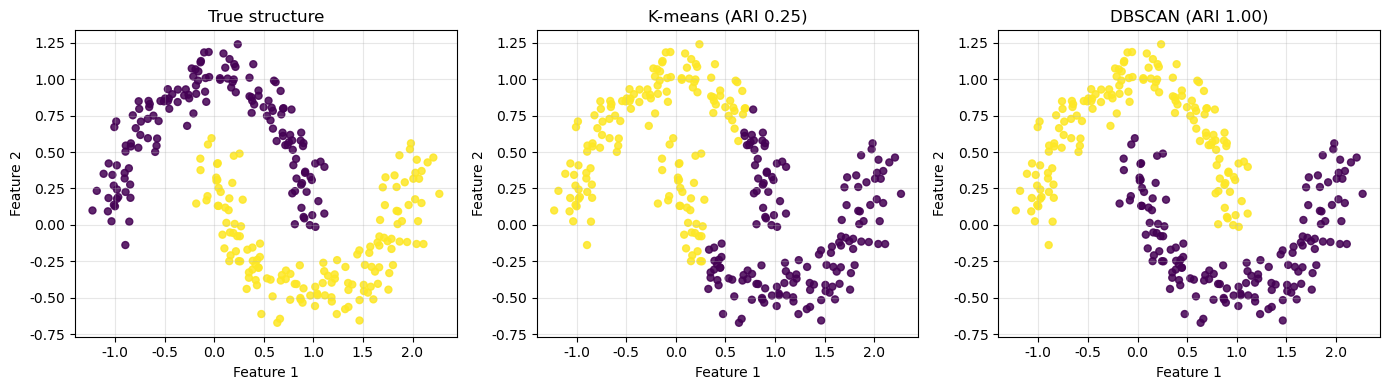

In [9]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

kmeans_for_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_moons = kmeans_for_moons.fit_predict(X_moons)

dbscan_for_moons = DBSCAN(eps=0.2, min_samples=5)
dbscan_moons = dbscan_for_moons.fit_predict(X_moons)

ari_kmeans = adjusted_rand_score(y_moons, kmeans_moons)
ari_dbscan = adjusted_rand_score(y_moons, dbscan_moons)

cluster_ids_moons = set(dbscan_moons)
cluster_ids_moons.discard(-1)        # -1 marks noise, not a cluster

print(f'K-means ARI : {ari_kmeans:.4f}')
print(f'DBSCAN  ARI : {ari_dbscan:.4f}')
print(f'DBSCAN found {len(cluster_ids_moons)} clusters, '
      f'{int((dbscan_moons == -1).sum())} noise points')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=25, alpha=0.85)
axes[0].set_title('True structure')
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_moons, cmap='viridis', s=25, alpha=0.85)
axes[1].set_title(f'K-means (ARI {ari_kmeans:.2f})')
axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_moons, cmap='viridis', s=25, alpha=0.85)
axes[2].set_title(f'DBSCAN (ARI {ari_dbscan:.2f})')

for panel_axis in axes:
    panel_axis.set_xlabel('Feature 1'); panel_axis.set_ylabel('Feature 2'); panel_axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

K-means cuts the crescents with a straight line — ARI 0.25, barely better than chance.
DBSCAN recovers them exactly (1.00), because each crescent is one connected dense region however it curves.

Next to Step 5 that is the honest summary: on Iris DBSCAN was the worse choice, on moons it is the only one
that works.
The algorithms encode different assumptions about what a cluster *is*, and the data decides which holds.

---
## Step 7. PCA

**PCA** finds the directions of largest variance: the first principal component is the direction the data
spreads most, the second the largest among directions orthogonal to it, and so on.
Projecting onto the first few keeps as much spread as possible.

`explained_variance_ratio_` gives the fraction each component carries.
PCA is a rotation, so it is sensitive to feature scale — another reason for standardizing.

explained variance ratio : [0.7296 0.2285 0.0367 0.0052]
cumulative               : [0.7296 0.9581 0.9948 1.    ]

2 of 4 components keep 95.8% of the variance


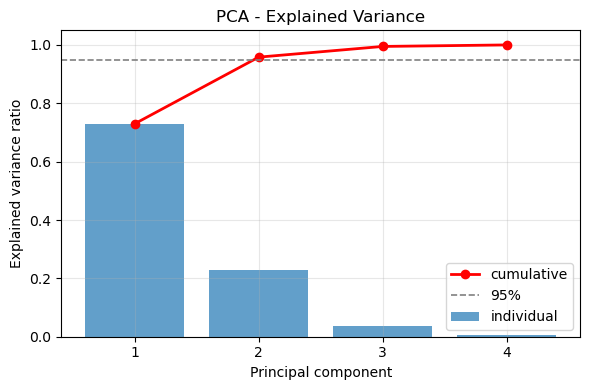

In [10]:
pca_full = PCA()
pca_full.fit(X)
explained = pca_full.explained_variance_ratio_

print('explained variance ratio :', explained.round(4))
print('cumulative               :', explained.cumsum().round(4))
print()
print(f'2 of 4 components keep {explained[:2].sum():.1%} of the variance')

fig, ax = plt.subplots(figsize=(6, 4))
components = range(1, len(explained) + 1)
ax.bar(components, explained, alpha=0.7, label='individual')
ax.plot(components, explained.cumsum(), 'ro-', linewidth=2, label='cumulative')
ax.axhline(0.95, color='gray', linestyle='--', linewidth=1.2, label='95%')
ax.set_xlabel('Principal component'); ax.set_ylabel('Explained variance ratio')
ax.set_title('PCA - Explained Variance'); ax.set_xticks(list(components))
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

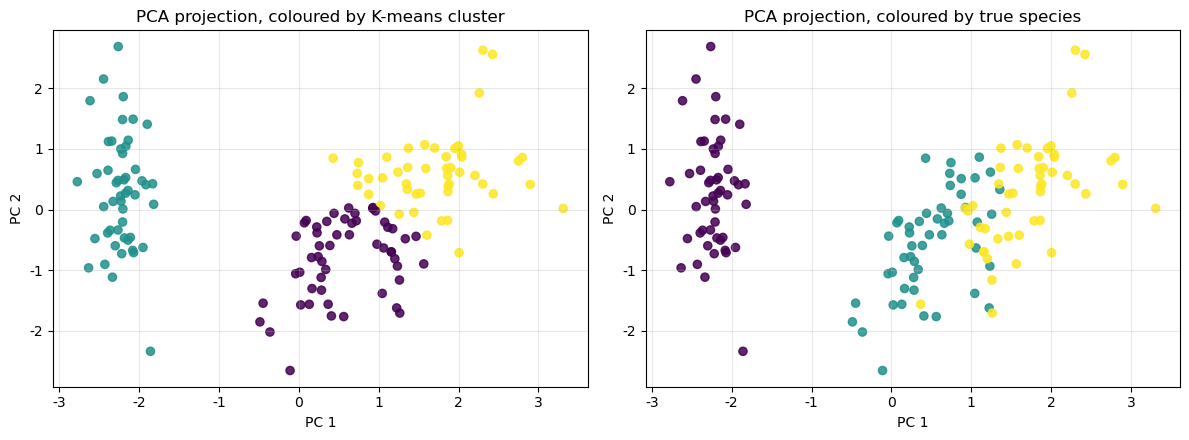

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=35, alpha=0.85)
axes[0].set_title('PCA projection, coloured by K-means cluster')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=35, alpha=0.85)
axes[1].set_title('PCA projection, coloured by true species')
for ax in axes:
    ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The left panel is the Step 3 clustering drawn in the PCA plane instead of against two raw features — a
fairer picture, since these two axes carry 96% of the variance.

Comparing the panels locates the disagreement: the leftmost group is separated by a wide gap and every
method finds it, while the boundary between the other two runs through a region with no gap.
That is why the silhouette preferred two clusters.

---
## Step 8. t-SNE

PCA can only rotate and project.
**t-SNE** measures which points are near each other in the original space and arranges them in two
dimensions so those neighbourhoods survive.

- Built for **looking at data**, not for features — there is no `transform` for new samples.
- **Distances between clusters are not meaningful**; only "these were neighbours" survives.
- `perplexity` (5 to 50) sets roughly how many neighbours to keep, and the method is stochastic, so fix
  `random_state`.

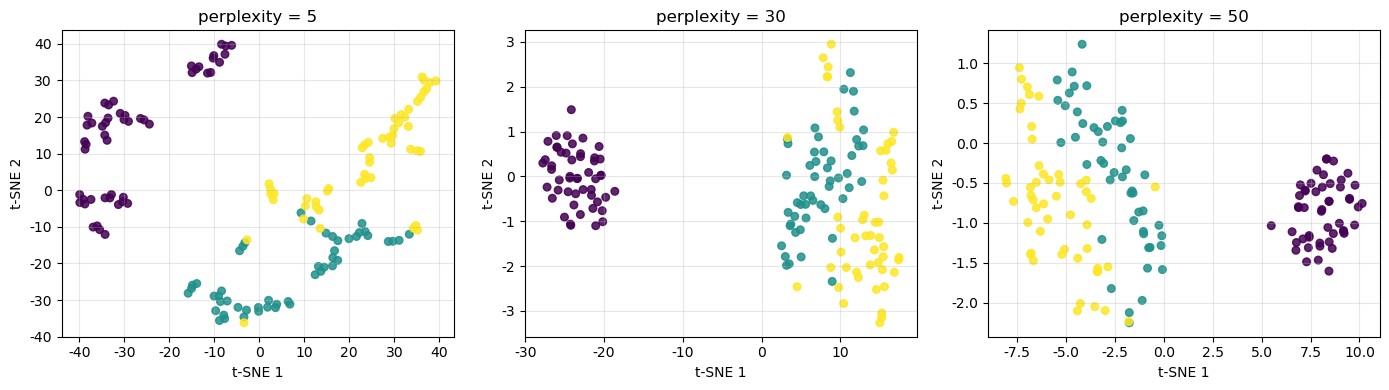

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, perplexity in zip(axes, [5, 30, 50]):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca')
    X_tsne = tsne.fit_transform(X)
    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='viridis', s=30, alpha=0.85)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.set_title(f'perplexity = {perplexity}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

All three settings separate the first species and keep the other two adjacent — the same structure PCA
showed.
`perplexity` changes how the points are packed: small keeps only very local relations and fragments the
groups, larger gives smoother blobs.

The agreement between PCA and t-SNE is a useful signal.
When only t-SNE shows separation, the next question is whether the parameters produced it.

| | PCA | t-SNE |
|:---|:---|:---|
| Transformation | linear | non-linear |
| Fitted quantity | directions of maximum variance | neighbourhood relationships |
| New samples | `transform` works | must refit |
| Distances between clusters | meaningful | not meaningful |
| Typical use | compression, preprocessing | visual inspection |

---
## Summary

| Method | Needs $k$ | Cluster shape assumed | Marks outliers |
|:---|:---|:---|:---|
| Hierarchical | no (cut height) | depends on the linkage | no |
| K-means | yes | round, similar size | no |
| DBSCAN | no (choose `eps`) | any connected dense region | yes, as `-1` |

1. **Standardize first**, or large units dominate every distance.
2. **The number of clusters is a choice** — the elbow said three, the silhouette said two.
3. **Internal indices measure shape, not correctness**; add an external one where labels exist.